In [1]:
import pandas as pd
import numpy as np


In [2]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [3]:
df=pd.read_csv('Airline_satisfaction.csv',index_col='ID')

In [4]:
df_original=pd.read_csv('Airline_satisfaction.csv',index_col='ID')

In [5]:
df.sample(20)

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
ID,,,,,,,,,,,,,,,,,,,,,
52773,Female,19,Returning,Business,Business,1874,2,19,5,5,...,3,4,1,4,4,1,5,4,4,Satisfied
99909,Male,34,Returning,Business,Business,1428,17,26,2,2,...,4,5,4,4,4,4,2,4,4,Satisfied
24501,Female,10,Returning,Personal,Economy,481,0,0,1,2,...,3,3,2,3,3,3,2,3,3,Neutral or Dissatisfied
61616,Female,21,First-time,Business,Business,1303,16,0,0,5,...,3,2,2,2,2,5,5,2,4,Satisfied
39710,Male,54,First-time,Business,Economy,205,1,11,0,2,...,2,3,4,3,3,1,2,3,4,Neutral or Dissatisfied
90521,Female,42,Returning,Business,Business,406,3,0,4,4,...,5,5,5,4,3,5,4,5,5,Satisfied
64257,Female,17,Returning,Personal,Economy,1660,2,6,4,1,...,4,4,3,3,3,5,1,3,5,Neutral or Dissatisfied
19050,Female,15,Returning,Personal,Economy,304,0,0,4,2,...,4,4,2,4,4,5,3,4,5,Neutral or Dissatisfied
82677,Female,41,Returning,Business,Business,3780,2,0,4,4,...,4,5,4,3,4,4,4,4,4,Satisfied


In [6]:
df.shape

(129880, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 1 to 129880
Data columns (total 23 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   Gender                                  129880 non-null  object
 1   Age                                     129880 non-null  int64 
 2   Customer Type                           129880 non-null  object
 3   Type of Travel                          129880 non-null  object
 4   Class                                   129880 non-null  object
 5   Flight Distance                         129880 non-null  int64 
 6   Departure Delay                         129880 non-null  int64 
 7   Arrival Delay                           129880 non-null  int64 
 8   Departure and Arrival Time Convenience  129880 non-null  int64 
 9   Ease of Online Booking                  129880 non-null  int64 
 10  Check-in Service                        129880 non-null  int6

In [8]:
df.describe()

,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,39.427957,1190.316392,14.713713,15.045465,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,15.119360,997.452477,38.071126,38.416353,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                          0
Satisfaction                    

In [11]:
df.dtypes

Gender                                    object
Age                                        int64
Customer Type                             object
Type of Travel                            object
Class                                     object
Flight Distance                            int64
Departure Delay                            int64
Arrival Delay                              int64
Departure and Arrival Time Convenience     int64
Ease of Online Booking                     int64
Check-in Service                           int64
Online Boarding                            int64
Gate Location                              int64
On-board Service                           int64
Seat Comfort                               int64
Leg Room Service                           int64
Cleanliness                                int64
Food and Drink                             int64
In-flight Service                          int64
In-flight Wifi Service                     int64
In-flight Entertainm

In [12]:
df['Satisfaction'].unique()

array(['Neutral or Dissatisfied', 'Satisfied'], dtype=object)

Encoding the objects/ Strings for analysis

In [13]:

df['Satisfaction'] = df['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

In [14]:


 ((df['Satisfaction']=='Satisfied').value_counts()/df.shape[0]*100)

Satisfaction
False    100.0
Name: count, dtype: float64

Satisfaction percentage is 43.44 %

In [15]:

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

## Male is encoded as 1 and Female as 0

In [16]:
df['Customer Type'] = df['Customer Type'].map({'First-time': 1, 'Returning': 0})

In [17]:
df['Type of Travel'] = df['Type of Travel'].map({'Personal': 0, 'Business': 1})

In [18]:

df['Class'] = df['Class'].map({'Economy': 0, 'Economy Plus': 1, 'Business': 2})

In [19]:
df.dtypes

Gender                                    int64
Age                                       int64
Customer Type                             int64
Type of Travel                            int64
Class                                     int64
Flight Distance                           int64
Departure Delay                           int64
Arrival Delay                             int64
Departure and Arrival Time Convenience    int64
Ease of Online Booking                    int64
Check-in Service                          int64
Online Boarding                           int64
Gate Location                             int64
On-board Service                          int64
Seat Comfort                              int64
Leg Room Service                          int64
Cleanliness                               int64
Food and Drink                            int64
In-flight Service                         int64
In-flight Wifi Service                    int64
In-flight Entertainment                 

In [20]:
df['Class'].unique()

array([2, 0, 1])

##Question 6 :- This graphs tells us the dependence of various factors on the satisfaction on the broader sense

In [21]:


correlation=df.corr()
color_pallete=['red','orange','orange','green','green','green','red','red','red','orange','orange','green','red','green','green','green','green','orange','green','green','green','green','green']

Text(0, 0.5, 'Correlation')

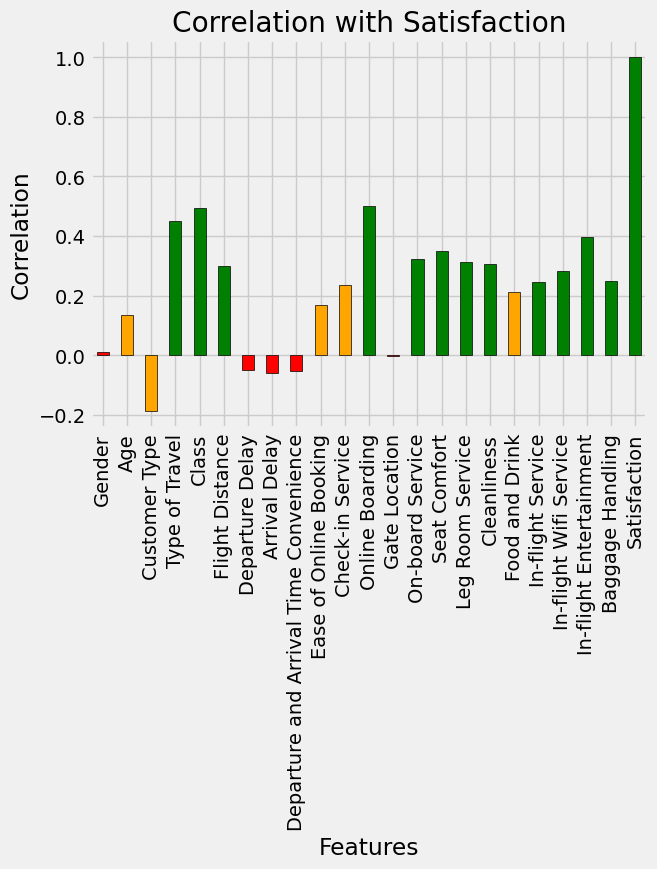

In [22]:
correlation['Satisfaction'].plot(kind='bar',color=color_pallete,edgecolor='black')
plt.title('Correlation with Satisfaction')
plt.xlabel('Features')
plt.ylabel('Correlation')

Text(0.5, 1.0, 'Visualisation of dependent factos on Satisfaction using Heatmap')

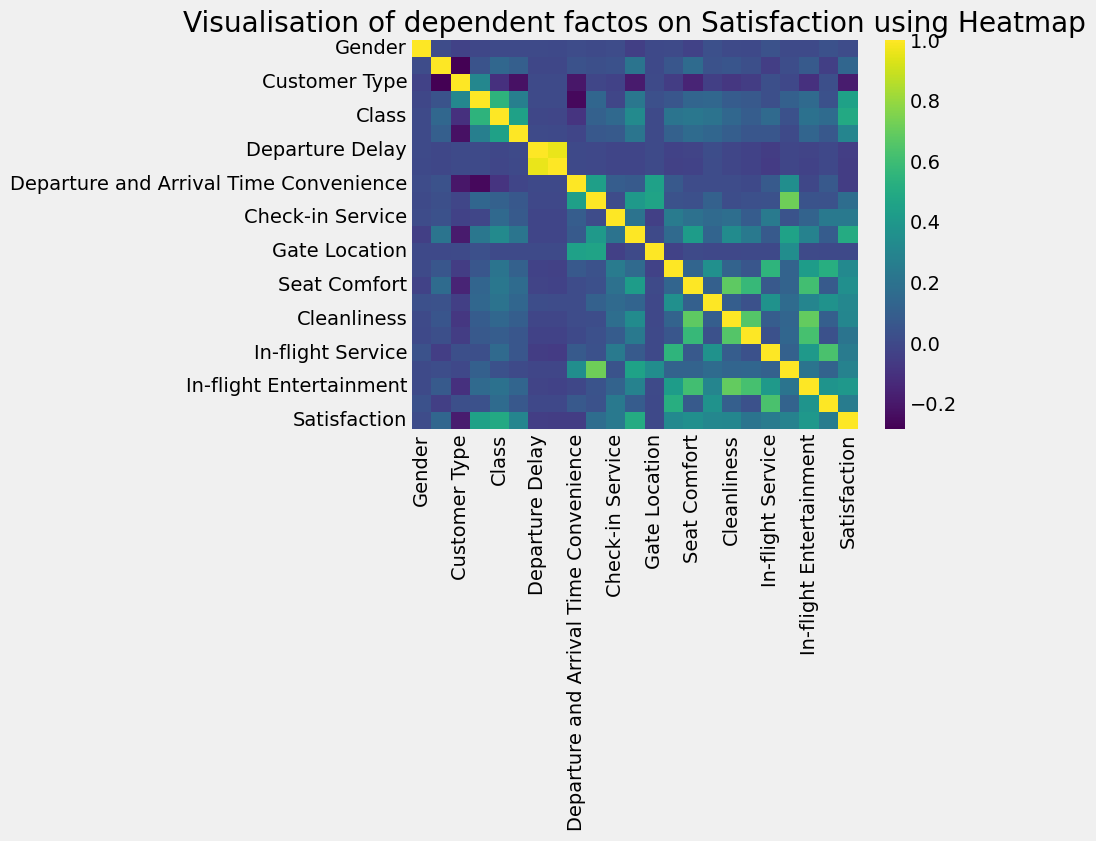

In [23]:

sns.heatmap(correlation,cmap='viridis',cbar=True)
plt.title("Visualisation of dependent factos on Satisfaction using Heatmap")

## Question 1 :- Satisfied V/s Not Satisfied (Neutral)

Text(0.5, 1.0, ' Satisfaction Percentage Distribution')

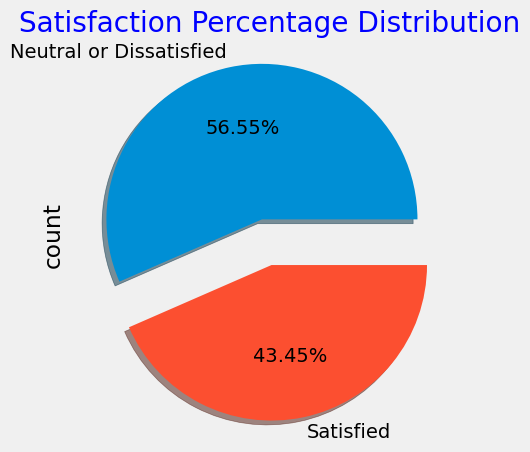

In [24]:
df_original['Satisfaction'].value_counts().plot(kind='pie',autopct='%.2f%%',shadow=True,explode=[0.1,0.2])
plt.title(" Satisfaction Percentage Distribution",color='Blue')

<Axes: xlabel='Satisfaction'>

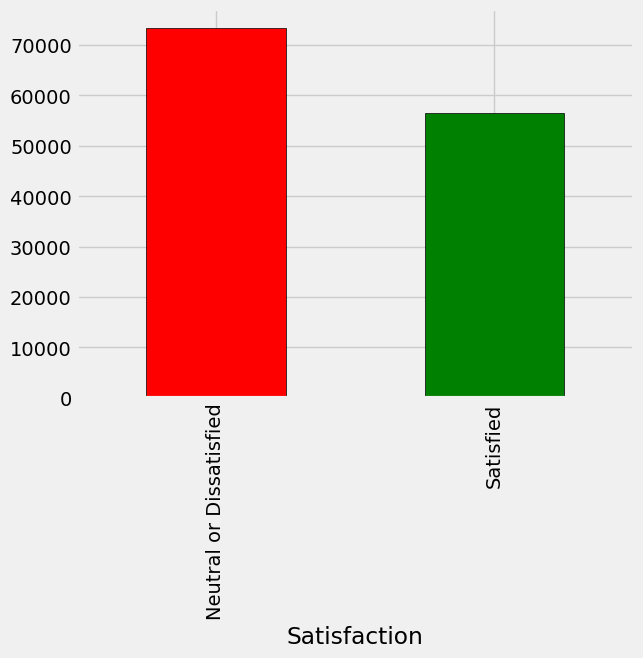

In [25]:
df_original['Satisfaction'].value_counts().plot(kind='bar',edgecolor='black',color=['red','green'])

## Variation with Customer Type

Text(0.5, 1.0, 'Varition with Pie Chart')

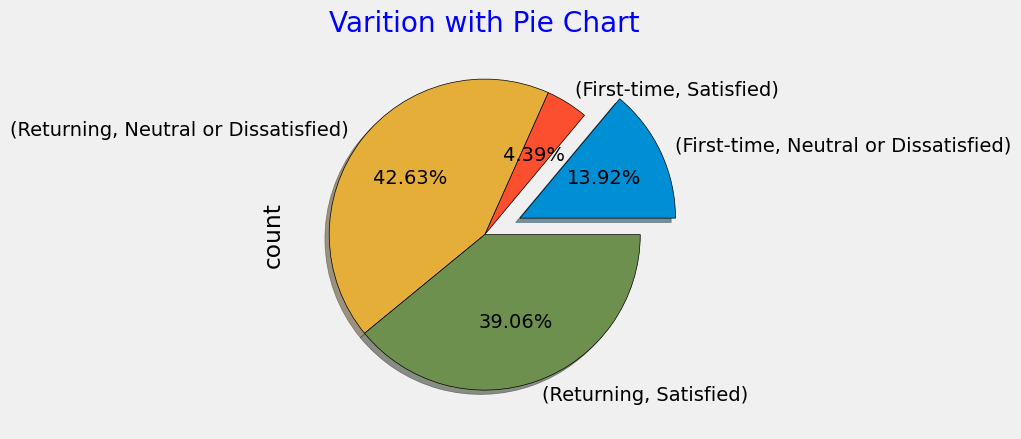

In [26]:
df_original.groupby('Customer Type')['Satisfaction'].value_counts().plot(kind='pie',autopct='%.2f%%',explode=[0.25,0,0,0],wedgeprops={'edgecolor':'black'},shadow=True)
plt.title('Varition with Pie Chart',color='Blue')


#### The first time traveller seems to be more dissatisfied on the distribution of the portion they occupy hence the factors and potential reasons are being explored

First time customer are 23700 out of which 18k are dissatisfied.

In [27]:

first_time=df_original[(df_original['Customer Type']=='First-time')&(df_original['Satisfaction']=='Neutral or Dissatisfied')]
first_time.shape[0]

18080

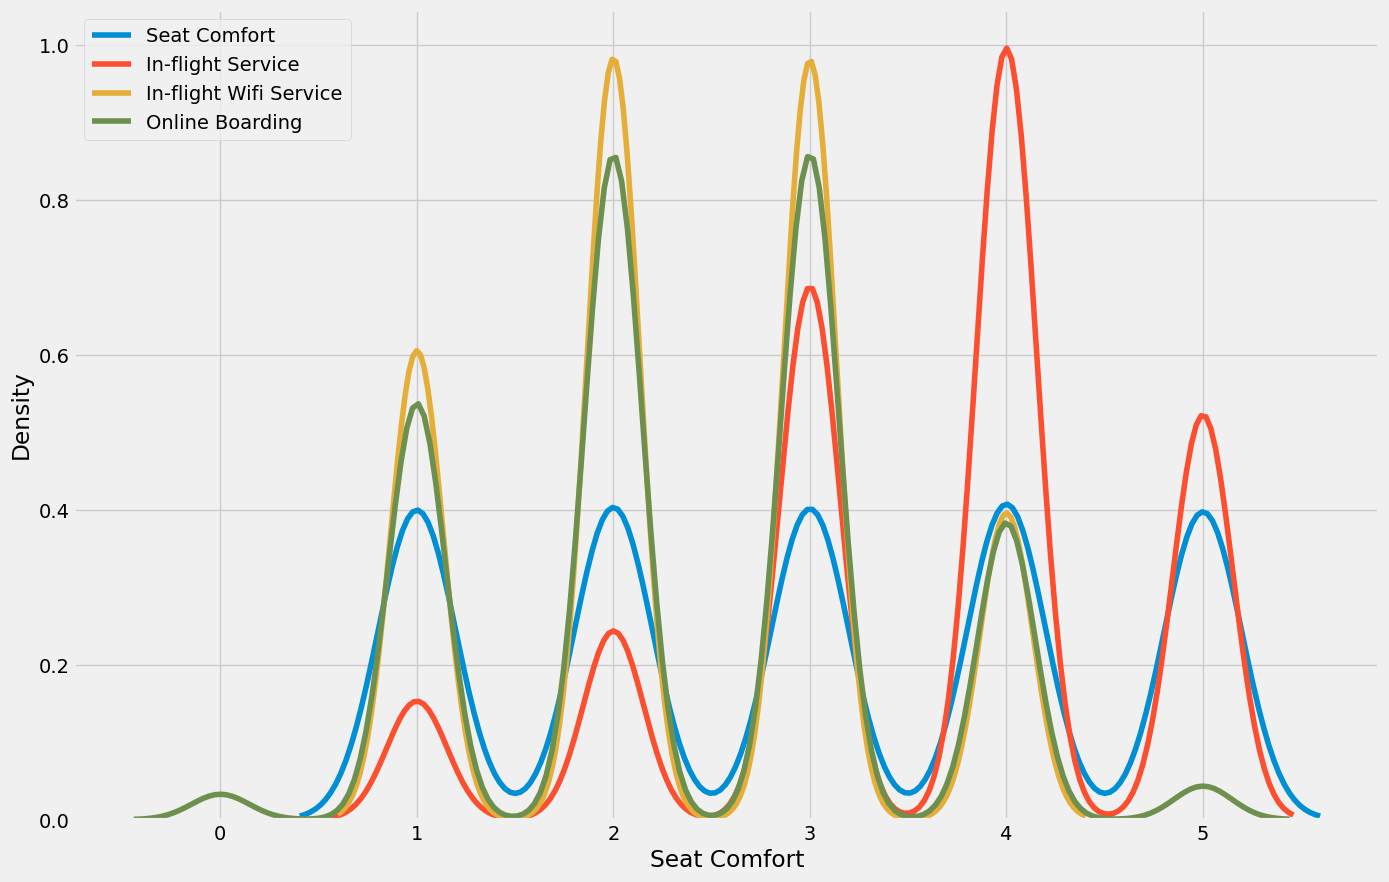

In [28]:
plt.figure(figsize=(15,10))
sns.kdeplot(data=first_time,x='Seat Comfort',label='Seat Comfort')
sns.kdeplot(data=first_time,x='In-flight Service',label='In-flight Service')
sns.kdeplot(data=first_time,x='In-flight Wifi Service',label='In-flight Wifi Service')
sns.kdeplot(data=first_time,x='Online Boarding',label='Online Boarding')
plt.legend(loc='upper left')

#### This gives us the conclusion that Online  Boarding, In-flight Wifi Service have sort of skewness, telling high density of being in avg ranked scores highlighting reasons of discomfort

<Axes: ylabel='Type of Travel'>

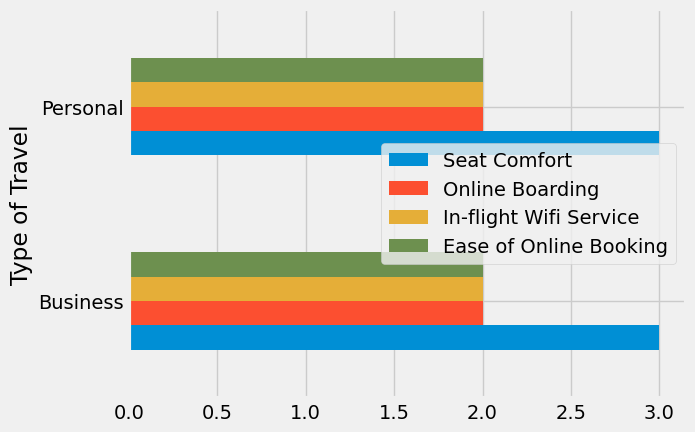

In [29]:
first_time.groupby(['Type of Travel'])[['Seat Comfort','Online Boarding','In-flight Wifi Service','Ease of Online Booking']].median().plot(kind='barh')


## Online Boarding may be a problem for first_time traveller

Online Boarding & Ease of Online Booking  along with In-flight Wifi services seems to be a flagged factor of discomfort and average experience

Seems like the first time travellers are finding it difficult to handle Online Booking and Boarding and also struggling with Wifi Services.

<Axes: ylabel='count'>

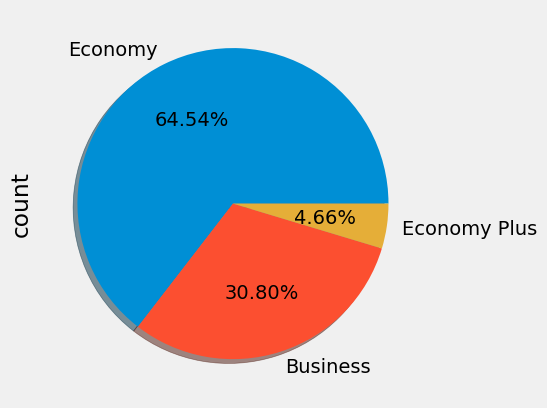

In [30]:
first_time['Class'].value_counts().plot(kind='pie',autopct='%.2f%%',textprops={'color': 'black'},shadow=True)

## Another reason is probably many visitor were taking the Economy Class found the travel less engaging

A lot of first time traveller are going with Economy class as a major preferrence, their expectation havent been carried to the optimum with the limitation of services in the Economy Class

In [31]:
df[(df['Customer Type']==1)].corr()
## Will help to decide what got wrong for the First time travellers

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
Gender,1.000000,-0.008512,NaN,-0.008807,0.018055,-0.001903,0.019359,0.016314,0.009460,0.018162,...,0.025428,-0.000857,0.017379,0.003397,0.002893,0.012767,0.018665,0.005456,0.014431,0.025384
Age,-0.008512,1.000000,NaN,-0.077908,0.197690,-0.076542,0.005291,0.005006,0.061187,-0.022719,...,0.004944,-0.006108,-0.000011,-0.009207,-0.010068,-0.022726,-0.018028,-0.010468,-0.024345,-0.121640
Customer Type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of Travel,-0.008807,-0.077908,NaN,1.000000,0.063818,-0.021274,0.004667,0.008225,-0.075253,0.013872,...,-0.006699,0.001370,0.000818,-0.000925,-0.001001,-0.008432,0.007811,-0.001016,-0.004416,0.017409
Class,0.018055,0.197690,NaN,0.063818,1.000000,0.092495,-0.027450,-0.033128,0.069338,0.118221,...,0.291401,-0.006349,0.125290,-0.005275,0.000492,0.362459,0.126514,0.007137,0.371760,0.281564
Flight Distance,-0.001903,-0.076542,NaN,-0.021274,0.092495,1.000000,0.004514,-0.002326,0.086923,0.016749,...,0.048547,0.001675,0.037148,-0.007191,-0.022124,0.059504,0.014640,-0.002967,0.039931,0.012217
Departure Delay,0.019359,0.005291,NaN,0.004667,-0.027450,0.004514,1.000000,0.959100,0.009839,-0.007071,...,-0.029111,0.006673,0.026580,0.004511,-0.028732,-0.079170,-0.009190,-0.003947,-0.021667,-0.034433
Arrival Delay,0.016314,0.005006,NaN,0.008225,-0.033128,-0.002326,0.959100,1.000000,0.005347,-0.010214,...,-0.034058,0.008964,0.023961,0.005460,-0.030785,-0.085902,-0.013347,-0.006371,-0.029011,-0.041413
Departure and Arrival Time Convenience,0.009460,0.061187,NaN,-0.075253,0.069338,0.086923,0.009839,0.005347,1.000000,0.391244,...,0.038229,-0.000612,0.016523,0.005953,0.025022,0.064623,0.367003,0.010225,0.076888,0.119481
Ease of Online Booking,0.018162,-0.022719,NaN,0.013872,0.118221,0.016749,-0.007071,-0.010214,0.391244,1.000000,...,0.085236,-0.001382,0.027270,0.004629,0.040697,0.088447,0.956503,0.010889,0.099456,0.411595


In [32]:
first_time['In-flight Wifi Service'].median()
## The other problem that first time travellers faced was In-flight Wifi Service
## Another reason is that they had issue with the complexity of booking flights

2.0

We have analysed the reason of people of first time as dissatisfied

In [33]:
(first_time[~(first_time['Ease of Online Booking']==0)])['Ease of Online Booking'].median() ## No problem for the NA of some values

2.0

In [34]:

first_time[~(first_time['In-flight Wifi Service']==0)]

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
ID,,,,,,,,,,,,,,,,,,,,,
1,Male,48,First-time,Business,Business,821,2,5,3,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
11,Female,28,First-time,Business,Business,821,0,5,1,1,...,2,2,5,2,2,4,1,2,3,Neutral or Dissatisfied
12,Female,27,First-time,Business,Business,421,20,21,2,2,...,2,2,5,1,1,3,1,1,4,Neutral or Dissatisfied
13,Male,24,First-time,Business,Economy,453,16,30,2,2,...,2,5,4,5,5,4,2,5,4,Neutral or Dissatisfied
31,Male,35,First-time,Business,Business,212,0,0,2,2,...,4,2,5,2,2,4,2,2,5,Neutral or Dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129755,Female,37,First-time,Business,Economy,337,1,13,2,1,...,2,1,2,1,1,3,1,1,4,Neutral or Dissatisfied
129759,Female,19,First-time,Business,Economy,337,0,0,0,1,...,4,3,3,3,3,5,2,3,3,Neutral or Dissatisfied
129869,Female,18,First-time,Business,Economy,337,0,0,0,2,...,4,5,4,5,5,4,2,5,4,Neutral or Dissatisfied


In [35]:
(first_time[~(first_time['Online Boarding']==0)])['Online Boarding'].median()

2.0

<Axes: ylabel='Type of Travel'>

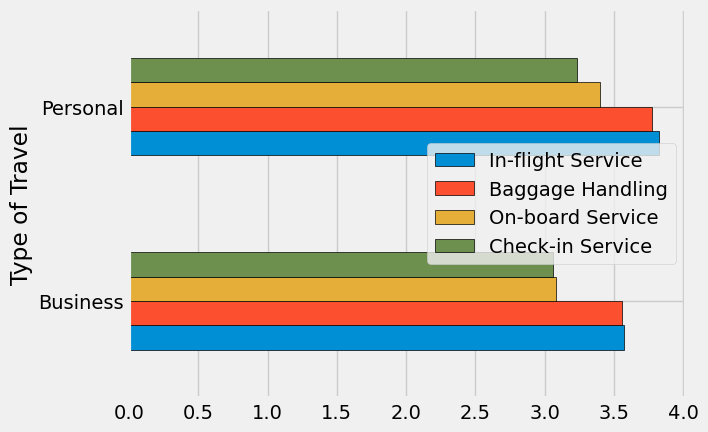

In [36]:
first_time.groupby(['Type of Travel'])[['In-flight Service','Baggage Handling','On-board Service','Check-in Service']].mean().plot(kind='barh',edgecolor='black')




## Looking at the variation with Type of Travel

In [37]:
df_original.groupby(['Type of Travel','Satisfaction'])['Satisfaction'].value_counts()

Type of Travel  Satisfaction           
Business        Neutral or Dissatisfied    37337
                Satisfied                  52356
Personal        Neutral or Dissatisfied    36115
                Satisfied                   4072
Name: count, dtype: int64

<Axes: xlabel='Type of Travel,Satisfaction'>

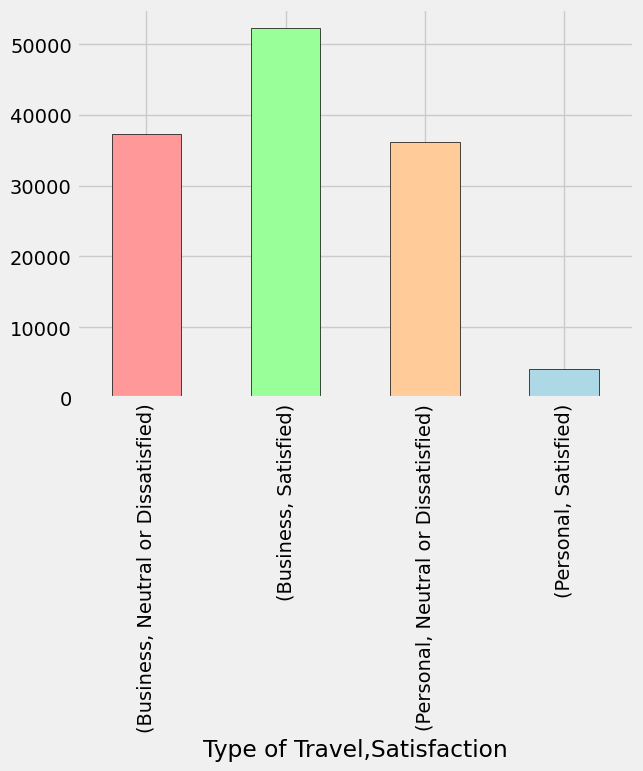

In [38]:
df_original.groupby(['Type of Travel','Satisfaction'])['Satisfaction'].value_counts().plot(kind='bar',color = ['#FF9999', '#99FF99', '#FFCC99', '#ADD8E6'],edgecolor='black')

Less counts of Personal Travels as for the Satisfaction is a identificable issue and reason are being explored

<Axes: ylabel='count'>

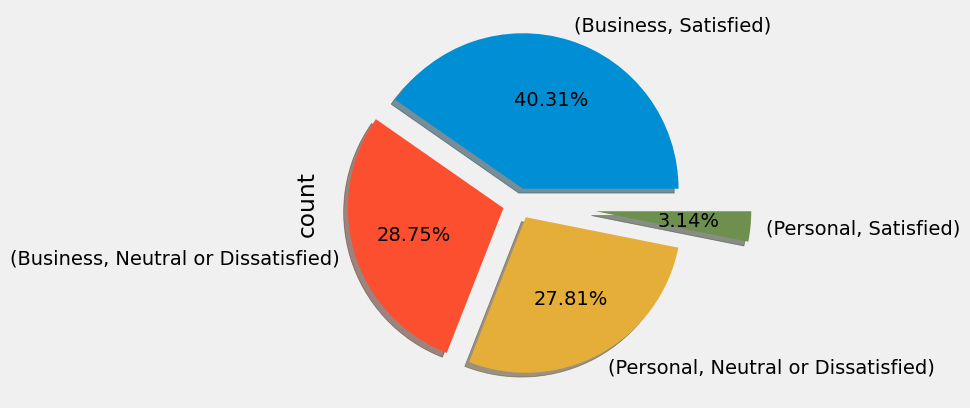

In [39]:

df_original.groupby('Type of Travel')['Satisfaction'].value_counts().plot(kind='pie',autopct='%.2f%%',textprops={'color':'black'},shadow=True,explode=[0.1,0.1,0.1,0.5])

#### Looking for which reason Personal travelles are low count of Satisfaction

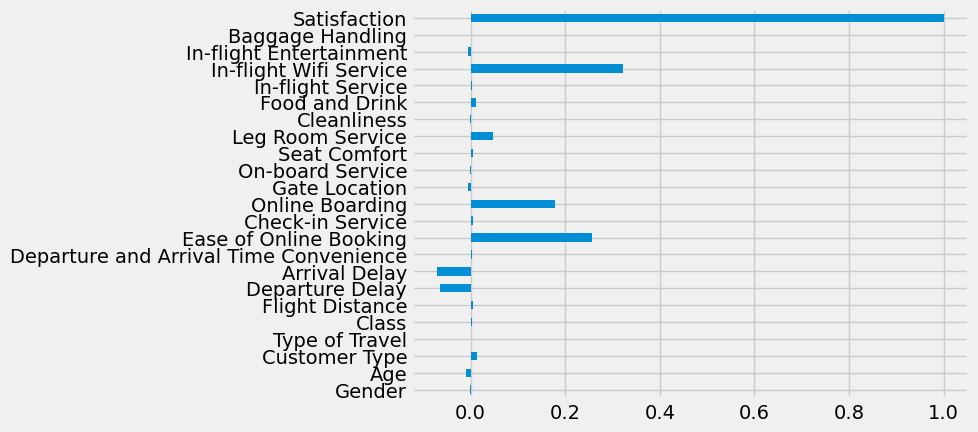

In [40]:
random1=(df[df['Type of Travel']==0]).corr()['Satisfaction'].plot(kind='barh')


In [41]:
personal_dissatisfied=df_original[(df_original['Type of Travel']=='Personal')&(df_original['Satisfaction']=='Neutral or Dissatisfied')]

Correalation is helpful in finding the reasons for the average experience of the Travellers

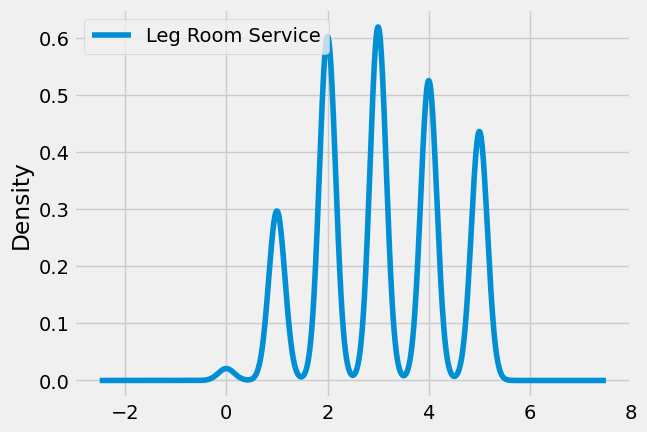

In [42]:
personal_dissatisfied['Leg Room Service'].plot(kind='kde',label='Leg Room Service')

plt.legend()

Leg Room is a problem for the personal travellers and has a median of 3. Airlines may look into this for enhancing the experience

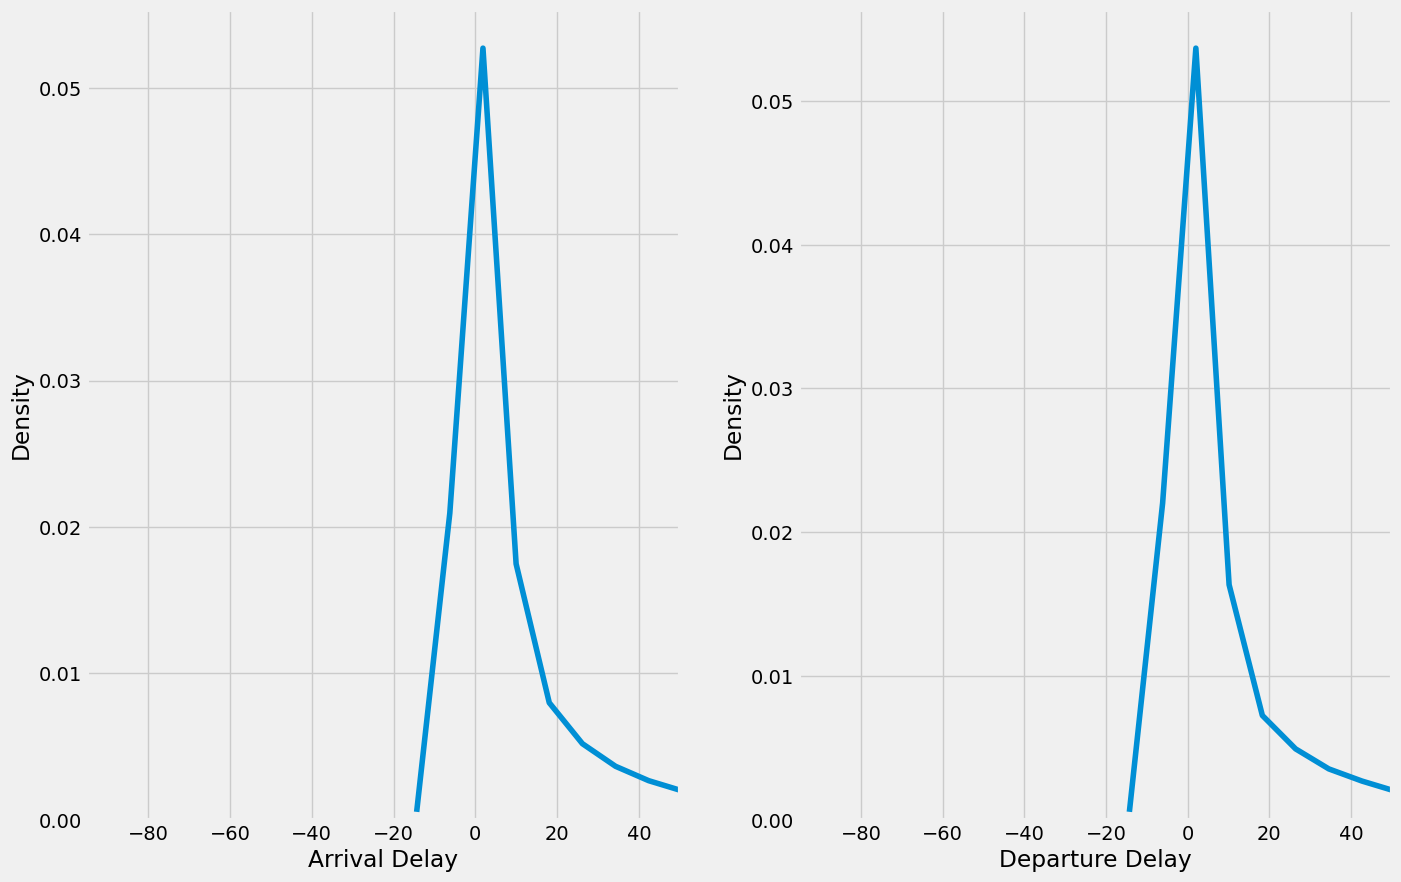

In [43]:


plt.figure(figsize=(15, 10))


plt.subplot(121)
sns.kdeplot(data=personal_dissatisfied, x='Arrival Delay')
plt.xlim(right=50)

# Second subplot
plt.subplot(122)
sns.kdeplot(data=personal_dissatisfied, x='Departure Delay')
plt.xlim(right=50)

# Display the plots
plt.show()


In [44]:
personal_dissatisfied['Departure Delay'].mean()
personal_dissatisfied['Departure Delay'].std()
print(personal_dissatisfied['Departure Delay'].mean(),
personal_dissatisfied['Departure Delay'].std())


15.201855184826249 38.842217381729974


In [45]:
personal_dissatisfied['Arrival Delay'].mean()
personal_dissatisfied['Arrival Delay'].std()
print(personal_dissatisfied['Arrival Delay'].mean(),
personal_dissatisfied['Arrival Delay'].std())

15.600359961234943 39.07156895445964


This shows the heavy Probability Density around the same region for dissatisfied passengers and standard deviation considerably high highlighting the discomfort caused due to delay.
Correlation KDE Plot and mean and standard deviation speak in the favour

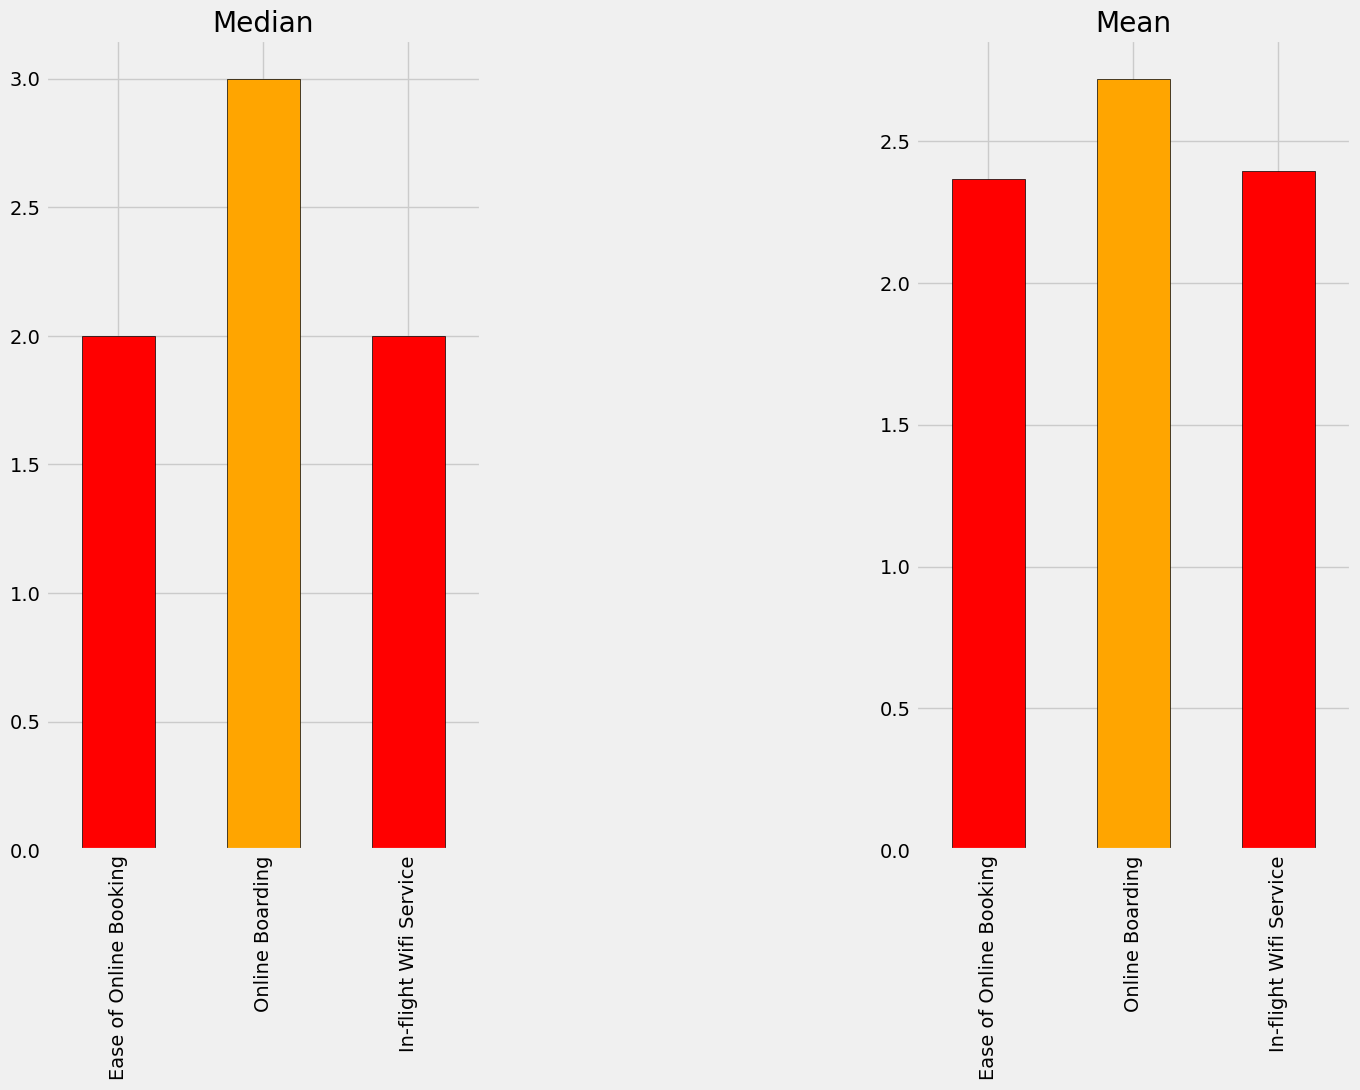

In [46]:
plt.figure(figsize=(15,10))
plt.subplot(121)
(personal_dissatisfied[['Ease of Online Booking','Online Boarding','In-flight Wifi Service']]).median().plot(kind='bar',color=['red','orange','red'],edgecolor='black')
plt.title("Median")
plt.subplot(122)
(personal_dissatisfied[['Ease of Online Booking','Online Boarding','In-flight Wifi Service']]).mean().plot(kind='bar',color=['red','orange','red'],edgecolor='black')
plt.title('Mean')
plt.subplots_adjust(wspace=1)

### The following are the reason for huge percentage of Dissatisfied Personal Travel

*   Ease of Online Boarding
*   In-flight Wifi Services

*   Online Boarding








Need to explore more of the type of travel to satisfaction


# Question 2

In [47]:
returning=df_original[df_original['Customer Type']=='Returning']
returning

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
ID,,,,,,,,,,,,,,,,,,,,,
2,Female,35,Returning,Business,Business,821,26,39,2,2,...,5,4,5,5,3,5,2,5,5,Satisfied
3,Male,41,Returning,Business,Business,853,0,0,4,4,...,3,5,3,5,5,3,4,3,3,Satisfied
4,Male,50,Returning,Business,Business,1905,0,0,2,2,...,5,5,5,4,4,5,2,5,5,Satisfied
5,Female,49,Returning,Business,Business,3470,0,1,3,3,...,3,4,4,5,4,3,3,3,3,Satisfied
6,Male,43,Returning,Business,Business,3788,0,0,4,4,...,4,4,4,3,3,4,4,4,4,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129876,Male,28,Returning,Personal,Economy Plus,447,2,3,4,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129877,Male,41,Returning,Personal,Economy Plus,308,0,0,5,3,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129878,Male,42,Returning,Personal,Economy Plus,337,6,14,5,2,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied


In [48]:
returning['Satisfaction'].value_counts()


Satisfaction
Neutral or Dissatisfied    55372
Satisfied                  50728
Name: count, dtype: int64

Text(0.5, 1.0, 'Returning Passengers and their Satisfaction Distribution Against Type of Travel')

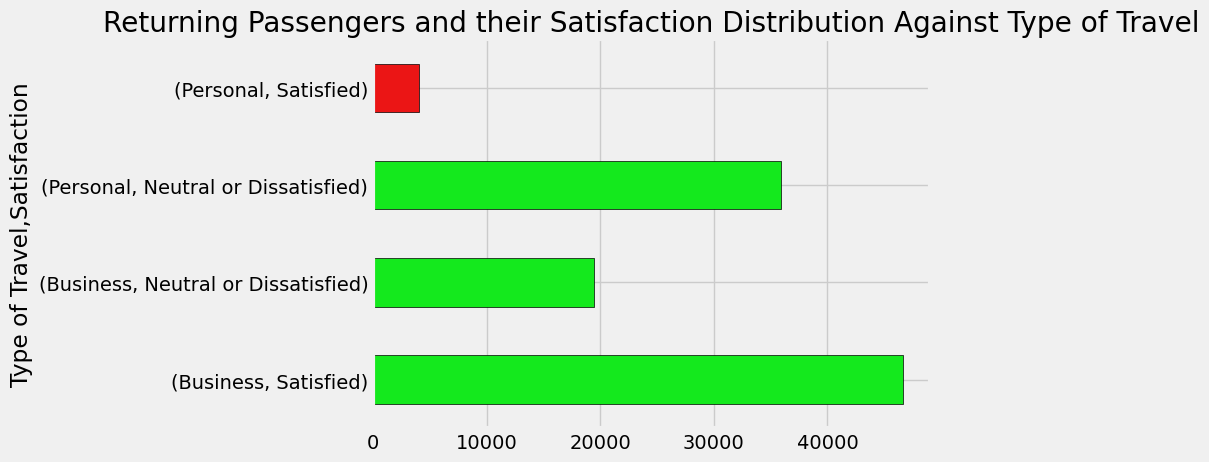

In [49]:
returning.groupby('Type of Travel')['Satisfaction'].value_counts().plot(kind='barh',color=['#14E91D','#14E91D','#14E91D','#EB1515'],edgecolor='black')
plt.title("Returning Passengers and their Satisfaction Distribution Against Type of Travel")

In [50]:
df_first_time=df[df['Customer Type']==1]

In [51]:
df_first_time

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
ID,,,,,,,,,,,,,,,,,,,,,
1,1,48,1,1,2,821,2,5,3,3,...,3,5,2,5,5,5,3,5,5,0
11,0,28,1,1,2,821,0,5,1,1,...,2,2,5,2,2,4,1,2,3,0
12,0,27,1,1,2,421,20,21,2,2,...,2,2,5,1,1,3,1,1,4,0
13,1,24,1,1,0,453,16,30,2,2,...,2,5,4,5,5,4,2,5,4,0
31,1,35,1,1,2,212,0,0,2,2,...,4,2,5,2,2,4,2,2,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129860,1,22,1,1,2,447,0,0,1,0,...,3,2,2,2,2,4,0,2,4,1
129867,0,20,1,1,0,447,0,4,0,4,...,3,5,3,4,4,5,4,4,4,1
129869,0,18,1,1,0,337,0,0,0,2,...,4,5,4,5,5,4,2,5,4,0


## Pie Chart for Visualisation

<Axes: ylabel='count'>

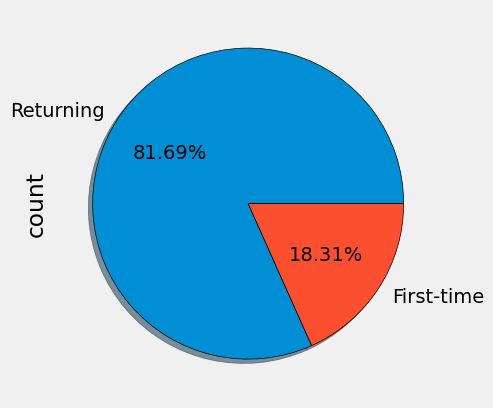

In [52]:
df_original['Customer Type'].value_counts().plot(kind='pie',autopct='%.2f%%',textprops={'color':'black'},wedgeprops={'edgecolor': 'black'},shadow=True)

## Bar Chart of the Distribution

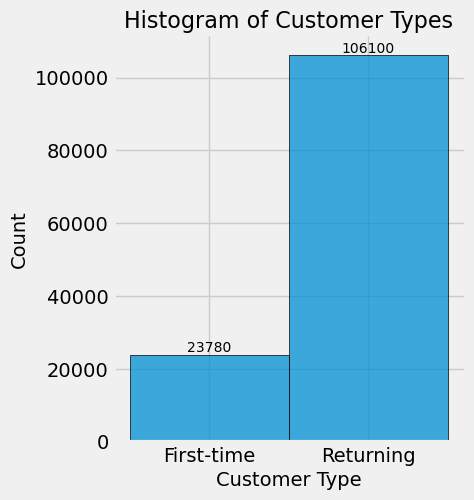

In [53]:

hist_plot = sns.displot(
    data=df_original,
    x='Customer Type',
    kind='hist',
    edgecolor='black'
)


ax = hist_plot.ax


for patch in ax.patches:
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height + 0.05,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )


ax.set_title('Histogram of Customer Types', fontsize=16)
ax.set_xlabel('Customer Type', fontsize=14)
ax.set_ylabel('Count', fontsize=14)


plt.show()

# Question 3

In [54]:
(df_original[df_original['Customer Type']=='First-time']).groupby('Gender')['Age'].mean()

Gender
Female    30.440473
Male      30.249337
Name: Age, dtype: float64

<Axes: ylabel='count'>

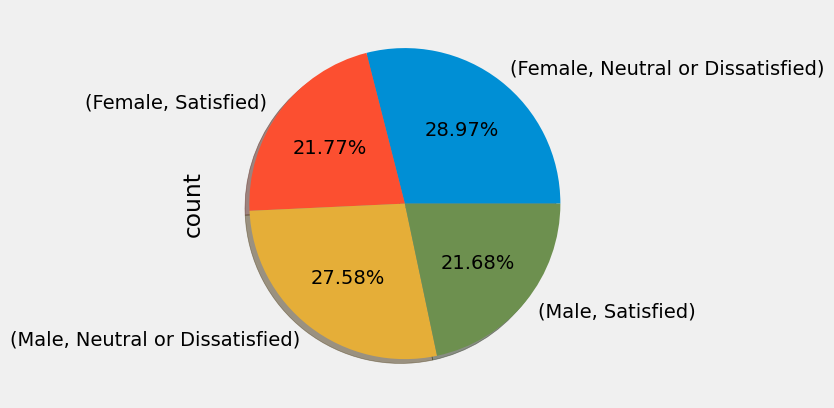

In [55]:
df_original.groupby('Gender')['Satisfaction'].value_counts().plot(kind='pie',autopct='%.2f%%',shadow=True)

In [56]:
(df[df['Gender']==1]).corr()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
Gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,NaN,1.000000,-0.280224,0.049984,0.137478,0.099804,-0.013948,-0.015950,0.030812,0.017740,...,0.059615,0.115740,0.074983,0.045398,0.015304,-0.011142,0.009467,0.071652,-0.007639,0.129658
Customer Type,NaN,-0.280224,1.000000,0.297994,-0.094965,-0.218730,0.011285,0.011810,-0.197773,-0.011503,...,-0.042747,-0.133920,-0.051151,-0.077246,-0.054005,0.010782,0.000785,-0.100771,0.014076,-0.172589
Type of Travel,NaN,0.049984,0.297994,1.000000,0.554174,0.275096,0.011456,0.011344,-0.256371,0.136309,...,0.032672,0.188945,0.085337,0.118763,0.089085,-0.040907,0.107792,0.158818,-0.026153,0.462207
Class,NaN,0.137478,-0.094965,0.554174,1.000000,0.451661,-0.006292,-0.010053,-0.097459,0.105198,...,0.205014,0.258355,0.176841,0.143440,0.093199,0.118741,0.032909,0.197310,0.130321,0.494118
Flight Distance,NaN,0.099804,-0.218730,0.275096,0.451661,1.000000,0.002036,-0.002251,-0.024423,0.067755,...,0.110012,0.170350,0.120381,0.093923,0.055816,0.046074,0.008648,0.132527,0.054161,0.298971
Departure Delay,NaN,-0.013948,0.011285,0.011456,-0.006292,0.002036,1.000000,0.959005,0.000203,-0.004976,...,-0.028880,-0.026032,0.013503,-0.018388,-0.031775,-0.056851,-0.015532,-0.027508,-0.006988,-0.051888
Arrival Delay,NaN,-0.015950,0.011810,0.011344,-0.010053,-0.002251,0.959005,1.000000,-0.002015,-0.006486,...,-0.033527,-0.028191,0.009499,-0.020547,-0.033411,-0.062520,-0.016277,-0.031259,-0.011932,-0.059248
Departure and Arrival Time Convenience,NaN,0.030812,-0.197773,-0.256371,-0.097459,-0.024423,0.000203,-0.002015,1.000000,0.432680,...,0.088398,-0.027743,0.023211,-0.019894,-0.008950,0.108522,0.339884,-0.014437,0.105042,-0.062549
Ease of Online Booking,NaN,0.017740,-0.011503,0.136309,0.105198,0.067755,-0.004976,-0.006486,0.432680,1.000000,...,0.029652,0.032931,0.044777,0.016924,0.031974,0.025583,0.711309,0.041403,0.032495,0.169230


In [57]:
(df[df['Gender']==0]).corr()


,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
Gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,NaN,1.000000,-0.287711,0.039935,0.143357,0.099071,-0.004198,-0.006546,0.042757,0.027142,...,0.054541,0.203364,0.004508,0.059511,0.030797,-0.089126,0.022472,0.078068,-0.085665,0.138226
Customer Type,NaN,-0.287711,1.000000,0.317760,-0.115350,-0.232905,-0.002999,-0.001770,-0.215066,-0.023794,...,-0.064297,-0.179969,-0.041198,-0.085045,-0.059739,0.036561,-0.011470,-0.110747,0.036461,-0.198098
Type of Travel,NaN,0.039935,0.317760,1.000000,0.537062,0.258750,0.000378,0.000635,-0.257695,0.132022,...,0.086195,0.065312,0.192530,0.051014,0.049377,0.084258,0.104099,0.147285,0.088516,0.438056
Class,NaN,0.143357,-0.115350,0.537062,1.000000,0.449966,-0.013527,-0.017885,-0.082804,0.109757,...,0.216922,0.196796,0.234012,0.133609,0.083425,0.190136,0.040673,0.195179,0.189892,0.491752
Flight Distance,NaN,0.099071,-0.232905,0.258750,0.449966,1.000000,0.002745,-0.001706,-0.013624,0.062605,...,0.112295,0.145315,0.147974,0.097320,0.058269,0.071417,0.004760,0.128524,0.074574,0.297181
Departure Delay,NaN,-0.004198,-0.002999,0.000378,-0.013527,0.002745,1.000000,0.959813,0.001293,-0.005704,...,-0.032143,-0.029849,0.015438,-0.010679,-0.026569,-0.052560,-0.016409,-0.026552,-0.001630,-0.049681
Arrival Delay,NaN,-0.006546,-0.001770,0.000635,-0.017885,-0.001706,0.959813,1.000000,-0.000027,-0.007616,...,-0.035819,-0.032608,0.013155,-0.012564,-0.029986,-0.057270,-0.019254,-0.029133,-0.004424,-0.057089
Departure and Arrival Time Convenience,NaN,0.042757,-0.215066,-0.257695,-0.082804,-0.013624,0.001293,-0.000027,1.000000,0.442367,...,0.046922,0.045786,-0.001925,0.038910,0.010001,0.038155,0.349750,-0.002584,0.038947,-0.046421
Ease of Online Booking,NaN,0.027142,-0.023794,0.132022,0.109757,0.062605,-0.005704,-0.007616,0.442367,1.000000,...,0.048050,0.024566,0.170974,0.013330,0.029077,0.044059,0.718199,0.051527,0.044936,0.168430


<Figure size 1500x1500 with 0 Axes>

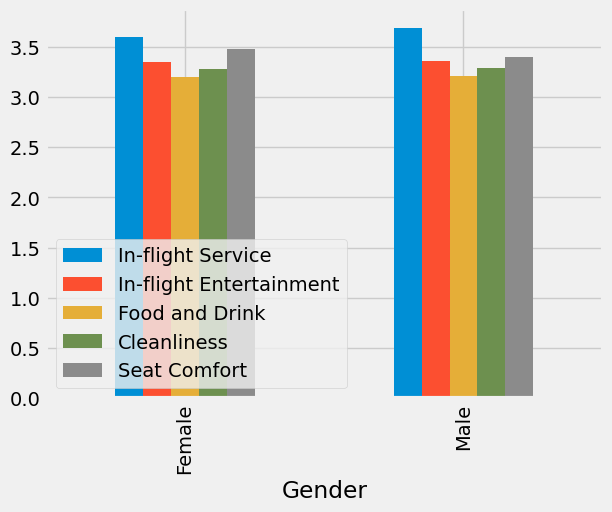

In [58]:
plt.figure(figsize=(15,15))
df_original.groupby('Gender')[['In-flight Service','In-flight Entertainment','Food and Drink','Cleanliness','Seat Comfort']].mean().plot(kind='bar')
plt.legend(loc='lower left')
plt.show()

<Axes: xlabel='Gender,Class'>

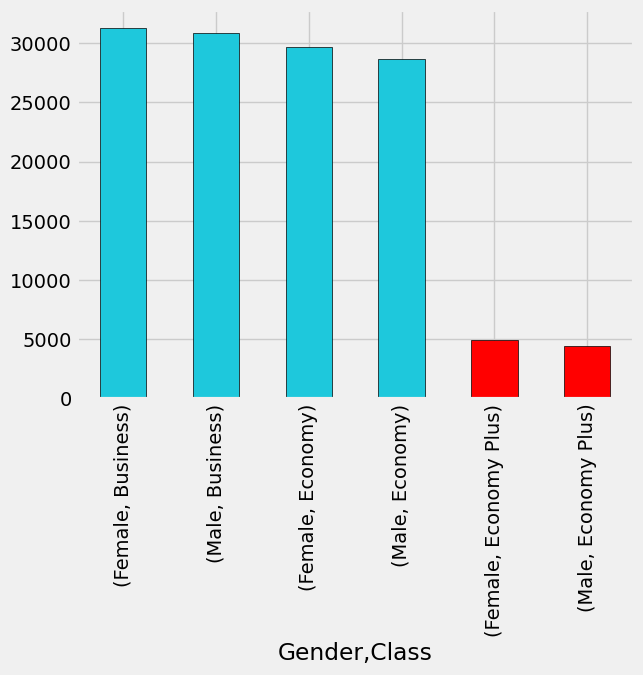

In [59]:
df_original[['Gender','Class']].value_counts().plot(kind='bar',color=['#1EC8DC','#1EC8DC','#1EC8DC','#1EC8DC','red','red'],edgecolor='black')

## Economy plus as really less preferred choice for class
## Can Explore why people are going so less with it

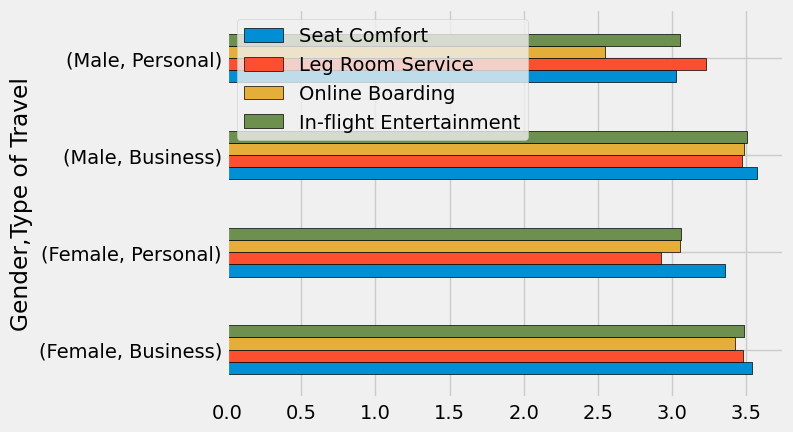

In [60]:
df_original.groupby(['Gender','Type of Travel'])[['Seat Comfort','Leg Room Service','Online Boarding','In-flight Entertainment']].mean().plot(kind='barh',edgecolor='black')
plt.legend(loc='upper left')
##  Male for Personal Travel seems to be quite dissatisfied for Online Boarding comparing the mean of other category

In [61]:
df_original.groupby(['Gender','Type of Travel'])[['Seat Comfort','Leg Room Service','Online Boarding','In-flight Entertainment']].median()

Seat Comfort  Leg Room Service  Online Boarding  \
Gender Type of Travel                                                    
Female Business                 4.0               4.0              4.0   
       Personal                 4.0               3.0              3.0   
Male   Business                 4.0               4.0              4.0   
       Personal                 3.0               3.0              3.0   

                       In-flight Entertainment  
Gender Type of Travel                           
Female Business                            4.0  
       Personal                            3.0  
Male   Business                            4.0  
       Personal                            3.0

The bar chart of mean and the median values grouped and evaluated above gives a lead that

1.   Female and Male going for Personal Travel find Leg Room Service,Online Boarding and In-flight Entertainment  less satisfactory than Business Travel respectively
2.   However Male in Personal Travel find the Seat Comfort also less satisfactory than Business unlike the females who rate equally.






### Conclusion :- This study paints a mindset on clear canvas that When people are going for Personal Travel they are more complaining and Dissatisfied for Seat Comfort, Leg Room Service etc than Business Travels.** Giving us the view that they become more complaining with the type of travel **

# Question 4

In [62]:
df_original[(df_original['Arrival Delay']==0)&(df_original['Departure Delay']!=0)].shape

(13648, 23)

In [63]:
unique_delay=df_original[(df_original['Departure Delay']!=0)&(df_original['Arrival Delay']==0)]

In [64]:

unique_delay_num=df[(df['Departure Delay']!=0)&(df['Arrival Delay']==0)]# unique_delay.corr()['Satisfaction']
# ## Angles to explore are Online Boarding Class and Type of Travel

<Axes: ylabel='Class,Satisfaction'>

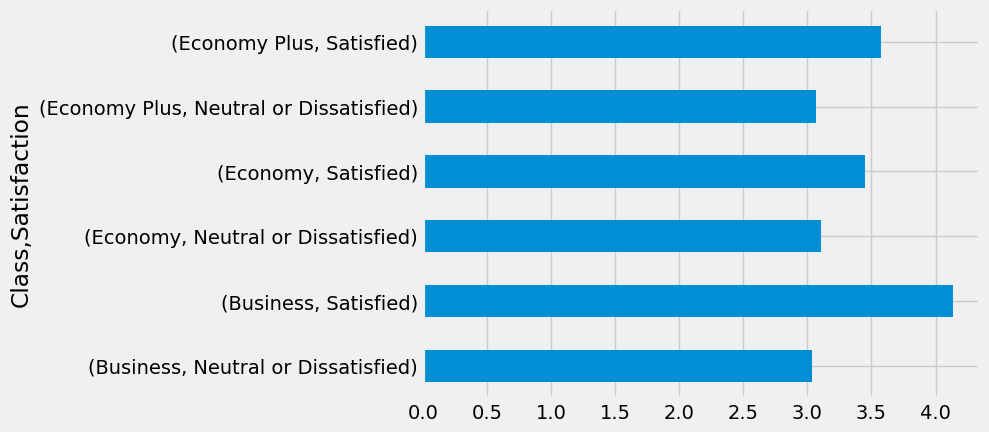

In [65]:
unique_delay.groupby(['Class','Satisfaction'])['Seat Comfort'].mean().plot(kind='barh')

<Axes: >

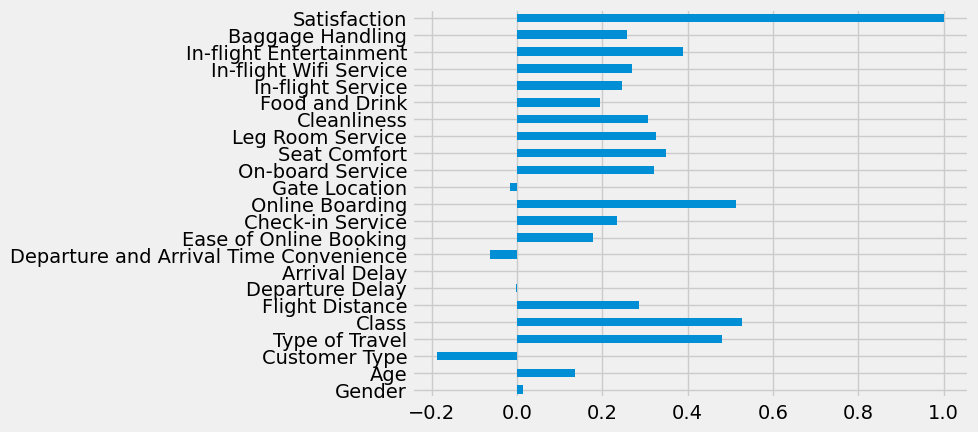

In [66]:
unique_delay_num.corr()['Satisfaction'].plot(kind='barh')

<Figure size 1500x1200 with 0 Axes>

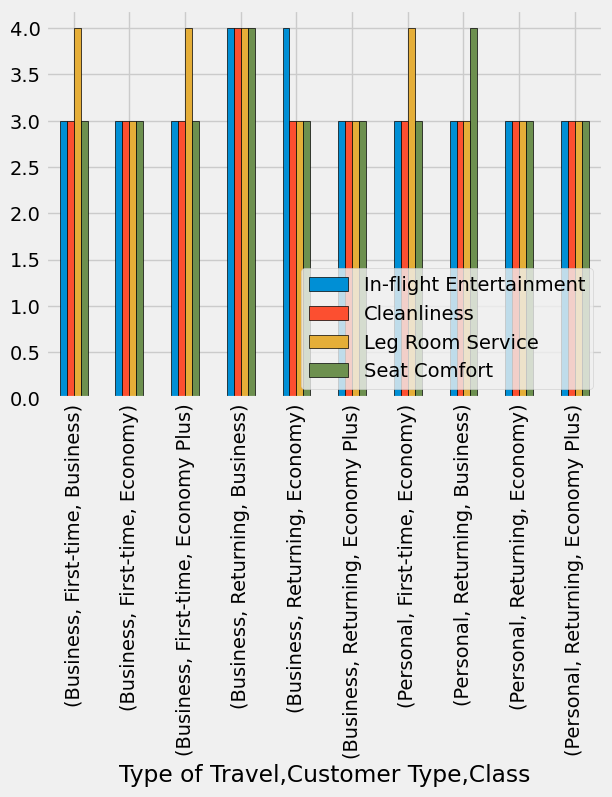

In [67]:
plt.figure(figsize=(15,12))
unique_delay.groupby(['Type of Travel','Customer Type','Class'])[['In-flight Entertainment','Cleanliness','Leg Room Service','Seat Comfort']].median().plot(kind='bar',edgecolor='black')
plt.legend(loc='lower right')

We can look for many trends within this bar chart aiming at various things.
Business Travels in Business Class for the returning passengers have been a smooth experiences in terms of the parameter mentioned with all the reading median around 4.
Leg Room service is strongly appreciated for the Business Travels First time in Business Class same goes for the third stack and seventh stacked bar chart.
Personal Travel Returning in Business Class have rated the Seat Comfort highly appreciating the Space.


# Question 5

<Axes: ylabel='count'>

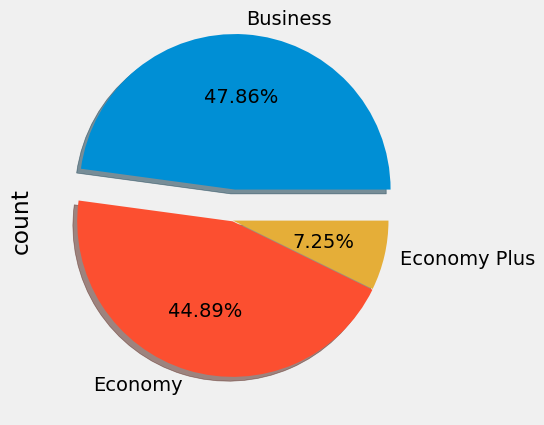

In [68]:
df_original['Class'].value_counts().plot(kind='pie',autopct='%.2f%%',textprops={'color':'black'},shadow=True,explode=[0.2,0.005,0])

<Axes: xlabel='Class'>

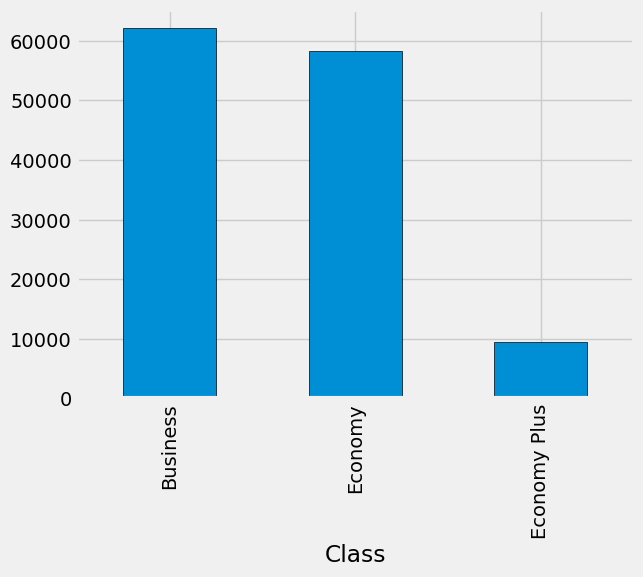

In [69]:
df_original['Class'].value_counts().plot(kind='bar',edgecolor='black')

In [70]:
df_original['Class'].value_counts()

Class
Business        62160
Economy         58309
Economy Plus     9411
Name: count, dtype: int64

# Question 7

In [71]:
df[['Flight Distance','Class']].corr()

,Flight Distance,Class
Flight Distance,1.000000,0.450814
Class,0.450814,1.000000


They exhibit strong positive correlation of 0.45

<Axes: ylabel='Class'>

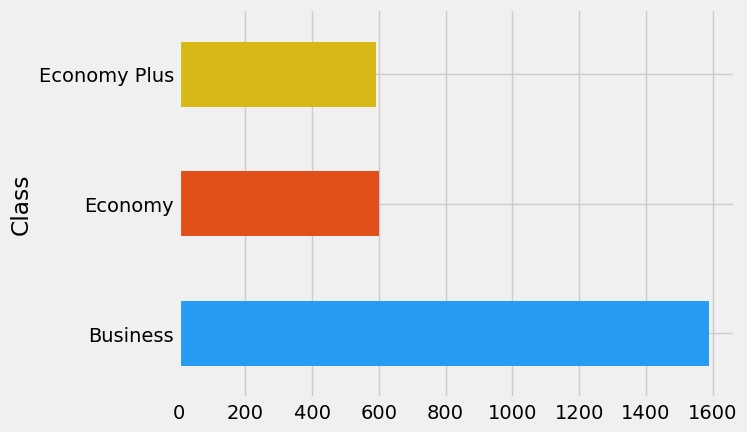

In [72]:
(df_original.groupby('Class'))['Flight Distance'].median().plot(kind='barh',color=['#269CF3','#E15019','#D8B817'])

# Business Class is a preferred choice for long distance flights

In [73]:
df['Flight Distance'].median()

844.0

In [74]:
df['Flight Distance'].std()

997.4524773267282

<Axes: ylabel='count'>

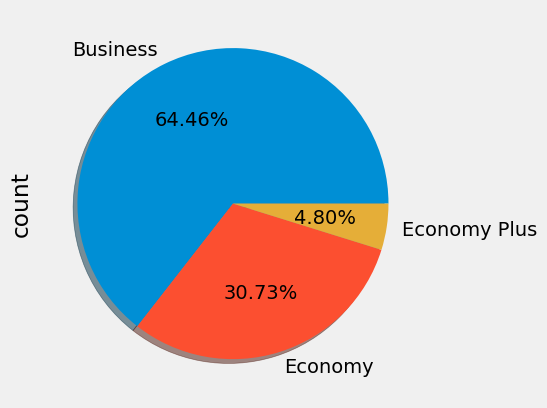

In [75]:
(df_original[df_original['Flight Distance']>844].groupby('Class'))['Class'].value_counts().plot(kind='pie',autopct='%.2f%%',textprops={'color':'black'},shadow=True)
## Almost 65% people are majorly travelling in Business Class when they are amongst the top 50 percentile of distance travelled

<Axes: xlabel='Flight Distance', ylabel='Density'>

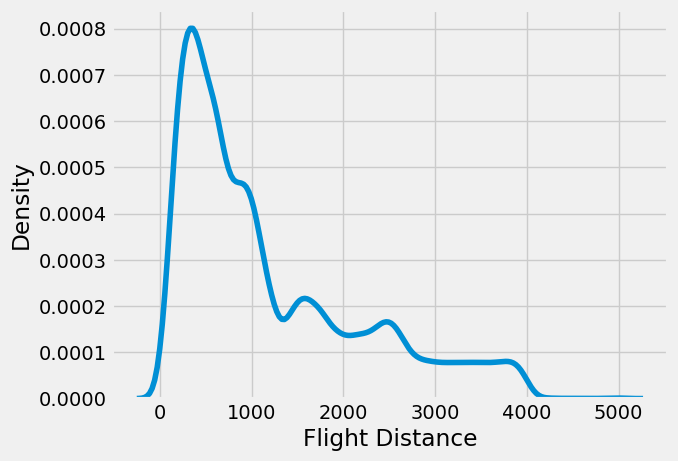

In [76]:
sns.kdeplot(data=df_original,x='Flight Distance')
## Refer that people are majorly travelling at relatively lower distances
## Flight Distance are skewed

In [77]:
(df[df['Flight Distance']>844]).corr()['Satisfaction']

Gender                                    0.013268
Age                                       0.159356
Customer Type                            -0.212554
Type of Travel                            0.470620
Class                                     0.530179
Flight Distance                           0.316376
Departure Delay                          -0.049174
Arrival Delay                            -0.056982
Departure and Arrival Time Convenience   -0.058679
Ease of Online Booking                    0.136806
Check-in Service                          0.299552
Online Boarding                           0.547414
Gate Location                            -0.002182
On-board Service                          0.387959
Seat Comfort                              0.420190
Leg Room Service                          0.377340
Cleanliness                               0.370689
Food and Drink                            0.245644
In-flight Service                         0.317266
In-flight Wifi Service         

In [78]:
(df[df['Flight Distance']>844])[['Seat Comfort','Leg Room Service','Cleanliness','In-flight Entertainment','Food and Drink']].mean()

Seat Comfort               3.591474
Leg Room Service           3.480158
Cleanliness                3.379074
In-flight Entertainment    3.475288
Food and Drink             3.260360
dtype: float64

In [79]:
(df[df['Flight Distance']>844])[['Seat Comfort','Leg Room Service','Cleanliness','In-flight Entertainment']].median()

Seat Comfort               4.0
Leg Room Service           4.0
Cleanliness                4.0
In-flight Entertainment    4.0
dtype: float64

This shows that when the flights are going for such large distances These factors contribute for the better satisfaction

<Axes: ylabel='count'>

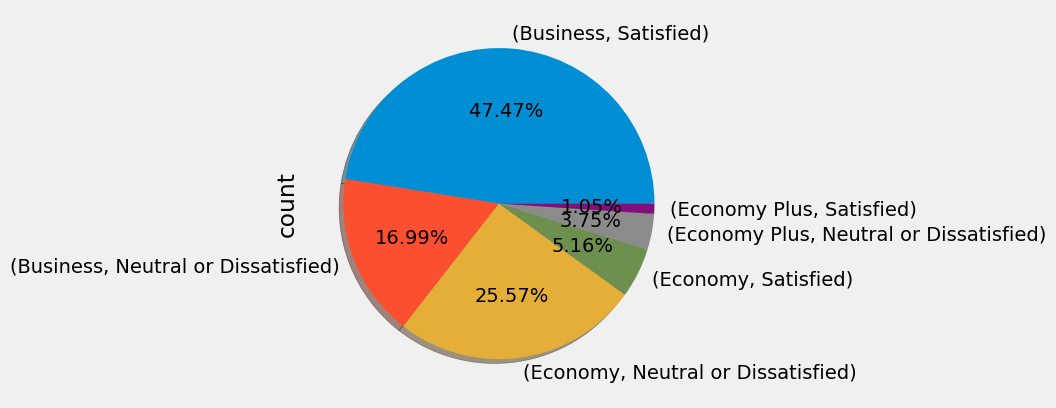

In [80]:
(df_original[df_original['Flight Distance']>844]).groupby('Class')['Satisfaction'].value_counts().plot(kind='pie',autopct='%.2f%%',textprops={'color':'black'},shadow=True)

In [81]:
(df_original[df_original['Flight Distance']>844].groupby('Class'))['Class'].value_counts()

Class
Business        41828
Economy         19942
Economy Plus     3117
Name: count, dtype: int64

<Axes: ylabel='count'>

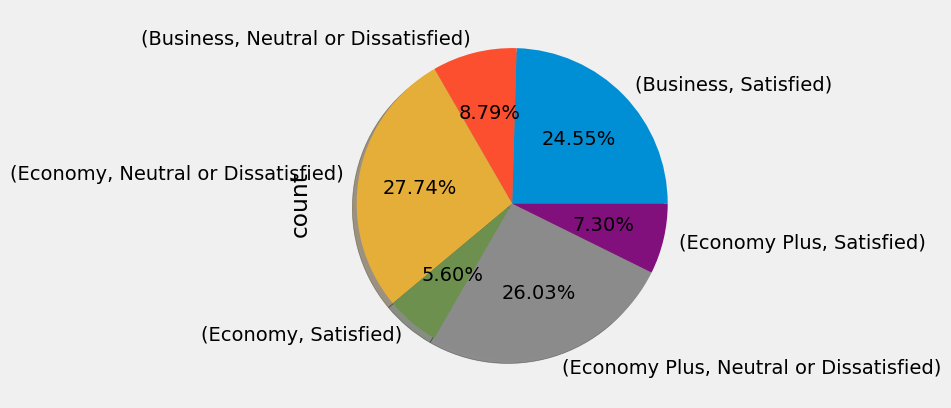

In [82]:

 ((df_original[df_original['Flight Distance']>844]).groupby('Class')['Satisfaction'].value_counts()/(df_original[df_original['Flight Distance']>844].groupby('Class'))['Class'].value_counts()).plot(kind='pie',autopct='%.2f%%',shadow=True,textprops={'color':'black'})

## This tells us that when travelling is there for large distance Business Class is a by far satisfactory as other economy and economy plus have high value of Dissatisfaction

We can plot a curve with taking correaltion as slope  but since the encoded class is a discrete numerical variable the distribution is tri-modal on the graph to plot and too absurd when tried to fit with such a regression line.
Class Wise Mean/Median/Standard Deviation of  Distance offers a better choice